# Best features for separation healthy vs MM

Top Separating Feature for monoe_40kev: original_firstorder_10Percentile
 -> Statistical Significance: p = 4.2471e-07 (H = 25.58)

Top Separating Feature for CaSupp_25: original_gldm_DependenceNonUniformity
 -> Statistical Significance: p = 4.5945e-07 (H = 25.43)

Top Separating Feature for konv: original_firstorder_10Percentile
 -> Statistical Significance: p = 3.6159e-07 (H = 25.89)



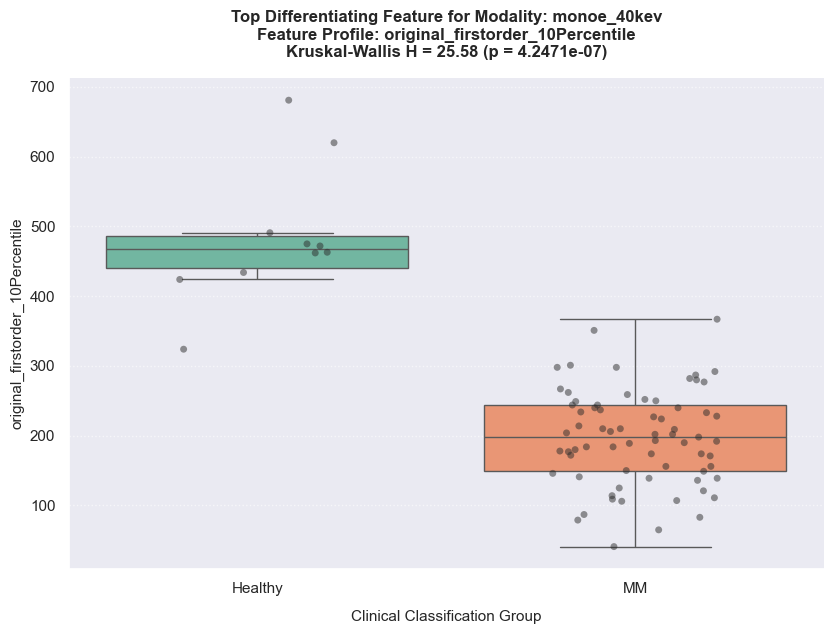

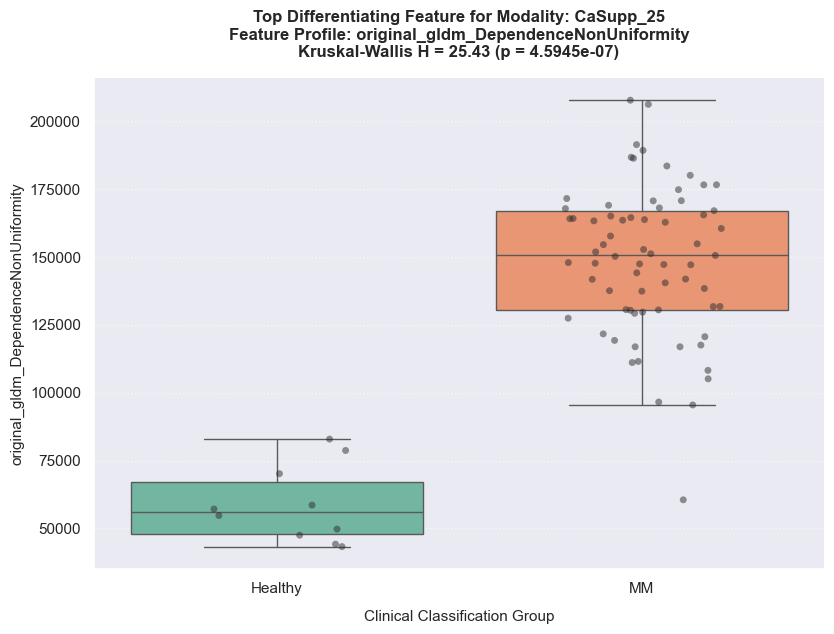

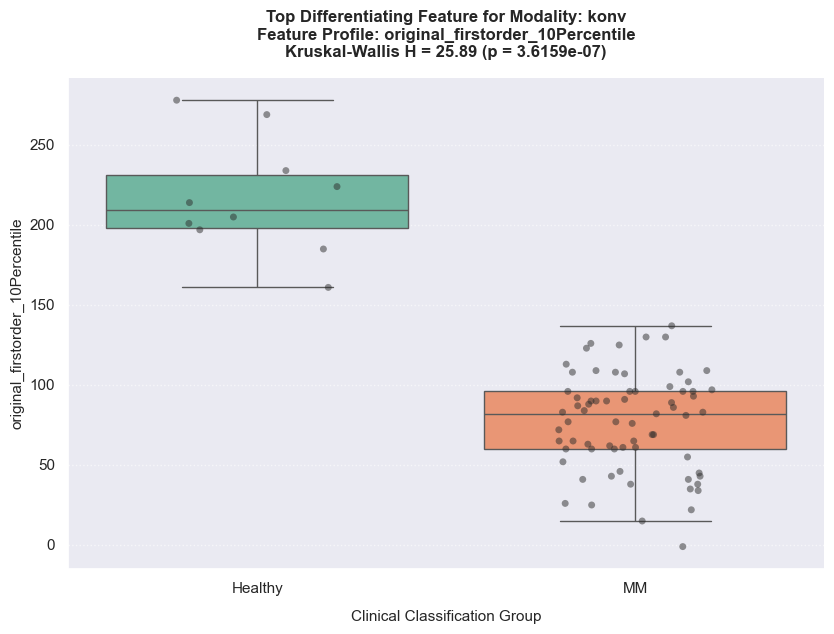

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal
import matplotlib.pyplot as plt

# 1. Global pandas settings and aesthetics configuration
pd.set_option('future.no_silent_downcasting', True)
sns.set_theme(style="darkgrid")

# Define target paths and configuration mappings
MAIN_PATH = Path(r"E:\DATA_Healthy_and_Myelom")

GROUPS_CONFIG = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "MM",
    "DATA_MM_Stage2": "MM",
    "DATA_MM_Stage3": "MM"
}

# Sort image types by string length descending to prevent substring matching collisions
IMAGE_TYPES = sorted(["CaSupp_25", "konv", "monoe_40kev"], key=len, reverse=True)
TARGET_SUFFIX = "radiomics_spine_features.csv"

all_extracted_records = []

# ==============================================================================
# 2. DATA EXTRACTION LOOP
# ==============================================================================
if MAIN_PATH.exists():
    for group_folder, group_label in GROUPS_CONFIG.items():
        group_dir_path = MAIN_PATH / group_folder
        if not group_dir_path.exists():
            continue

        for patient_folder in group_dir_path.iterdir():
            if not patient_folder.is_dir():
                continue

            for file_path in patient_folder.glob(f"*{TARGET_SUFFIX}"):
                file_name = file_path.name
                matched_img_type = None

                # Check for image type keywords using length-sorted priority
                for img_type_candidate in IMAGE_TYPES:
                    if img_type_candidate in file_name:
                        matched_img_type = img_type_candidate
                        break

                if matched_img_type:
                    try:
                        df_temp = pd.read_csv(file_path)
                        df_temp['Group'] = group_label  # Collapses Stage 1/2/3 down to "MM"
                        df_temp['ImageType'] = matched_img_type
                        df_temp['Patient'] = patient_folder.name
                        all_extracted_records.append(df_temp)
                    except Exception as parse_error:
                        print(f"Skipping unreadable file {file_name}: {parse_error}")

if not all_extracted_records:
    raise ValueError("Zero records compiled. Verify folder structures and filenames.")

full_df = pd.concat(all_extracted_records, ignore_index=True)

# ==============================================================================
# 3. STATISTICAL SEPARATION SELECTION (HEALTHY vs MM)
# ==============================================================================
final_visualizations_queue = []

for selected_img in IMAGE_TYPES:
    analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

    # Isolate strictly numerical feature columns
    metadata_cols = ['Group', 'ImageType', 'Patient']
    features_to_test = [col for col in analysis_df.columns if col not in metadata_cols]

    stats_results = []

    for feat in features_to_test:
        # Filter out static or constant columns
        if analysis_df[feat].nunique() <= 1:
            continue

        # Split into analytical target vectors
        group_healthy = analysis_df[analysis_df['Group'] == "Healthy"][feat].dropna()
        group_mm = analysis_df[analysis_df['Group'] == "MM"][feat].dropna()

        # Enforce minimum sample thresholds per vector
        if len(group_healthy) < 2 or len(group_mm) < 2:
            continue

        try:
            # Kruskal-Wallis serves as an excellent non-parametric separation evaluator
            h_stat, p_val = kruskal(group_healthy, group_mm)
            if not np.isnan(p_val):
                stats_results.append({
                    'Feature': feat,
                    'p-value': p_val,
                    'H-statistic': h_stat,
                    'ImageType': selected_img
                })
        except Exception:
            continue

    if stats_results:
        # Sort and isolate the unique highest performing feature (lowest p-value)
        results_df = pd.DataFrame(stats_results).sort_values('p-value')
        best_feature = results_df.iloc[0]
        final_visualizations_queue.append(best_feature)

        print(f"Top Separating Feature for {selected_img}: {best_feature['Feature']}")
        print(f" -> Statistical Significance: p = {best_feature['p-value']:.4e} (H = {best_feature['H-statistic']:.2f})\n")

# ==============================================================================
# 4. HIGH-DENSITY BOXPLOT GRAPH GENERATION
# ==============================================================================
for plot_item in final_visualizations_queue:
    feat_name = plot_item['Feature']
    img_modality = plot_item['ImageType']
    calculated_p = plot_item['p-value']
    calculated_h = plot_item['H-statistic']

    # Filter master dataset down to the current modality profile
    plot_data_subset = full_df[full_df['ImageType'] == img_modality]

    fig, ax = plt.subplots(figsize=(8.5, 6.5))

    # Static cohort color palette maps
    group_colors = {"Healthy": "#66c2a5", "MM": "#fc8d62"}

    # Generate boxplot container
    sns.boxplot(
        data=plot_data_subset,
        x='Group',
        y=feat_name,
        hue='Group',
        order=["Healthy", "MM"],
        palette=group_colors,
        showfliers=False,
        legend=False,
        ax=ax
    )

    # Superimpose high-density jitter points
    sns.stripplot(
        data=plot_data_subset,
        x='Group',
        y=feat_name,
        hue='Group',
        order=["Healthy", "MM"],
        palette=["#2b2b2b"] * 2,
        alpha=0.5,
        jitter=0.22,
        legend=False,
        ax=ax
    )

    # Format axis strings and titles cleanly in English
    ax.set_title(
        f"Top Differentiating Feature for Modality: {img_modality}\n"
        f"Feature Profile: {feat_name}\n"
        f"Kruskal-Wallis H = {calculated_h:.2f} (p = {calculated_p:.4e})",
        fontsize=12,
        pad=15,
        fontweight='bold'
    )

    ax.set_xlabel("Clinical Classification Group", fontsize=11, labelpad=10)
    ax.set_ylabel(feat_name, fontsize=11)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    sns.despine(fig=fig)

    plt.tight_layout()
    plt.show()